# Tree Search Comparison: PIP vs TKF

This notebook analyzes the performance and accuracy of **Poisson Indel Process (PIP)** and **Thorne-Kishino-Felsenstein (TKF)** models based on the results in `results/summary.tsv`.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import numpy as np
import statsmodels.api as sm

# Configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_csv('results/summary.tsv', sep='\t')

# Note: The 'gap_strategy' column seems to contain the model name (PIP/TKF92)
model_col = 'gap_strategy'

# Ensure numeric types for metrics
metrics = ['robinson_foulds', 'kuhner_felsenstein', 'runtime_seconds', 'log_likelihood', 'alignment_length', 'gap_percentage', 'species']
for col in metrics:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Loaded {len(df)} results.")
df.head()

Loaded 80 results.


,alignment_length,birth_rate,death_rate,gap_percentage,gap_strategy,ip,ir,jati_model,kuhner_felsenstein,log_likelihood,...,mutation_rate,robinson_foulds,runtime_seconds,sampling_fraction,seed,species,tkf_lambda,tkf_mu,tkf_r,tree_visualization
0,280,1.0,2.0,61.67,PIP,NaN,NaN,jc69,7.871443,-15590.522507,...,1.0,102.0,-75614.0,0.25,1,128,0.03,0.031,0.8,file:///Users/mrzi/Documents/develop/tree_sear...
1,280,1.0,2.0,61.67,TKF92,NaN,NaN,jc69,1.839279,-14295.062051,...,1.0,108.0,324.0,0.25,1,128,0.03,0.031,0.8,file:///Users/mrzi/Documents/develop/tree_sear...
2,307,1.0,2.0,57.63,PIP,NaN,NaN,jc69,1.573067,-17697.858019,...,1.0,74.0,4751.0,0.25,2,128,0.03,0.031,0.8,file:///Users/mrzi/Documents/develop/tree_sear...
3,307,1.0,2.0,57.63,TKF92,NaN,NaN,jc69,2.168904,-16295.595386,...,1.0,78.0,533.0,0.25,2,128,0.03,0.031,0.8,file:///Users/mrzi/Documents/develop/tree_sear...
4,1573,1.0,2.0,64.66,PIP,NaN,NaN,jc69,0.894806,-80273.380474,...,1.0,42.0,20108.0,0.25,3,128,0.03,0.031,0.8,file:///Users/mrzi/Documents/develop/tree_sear...


## 1. Topological Accuracy (Robinson-Foulds Distance)

The Robinson-Foulds (RF) distance measures the symmetric difference between the inferred tree and the true tree. **Lower is better.**

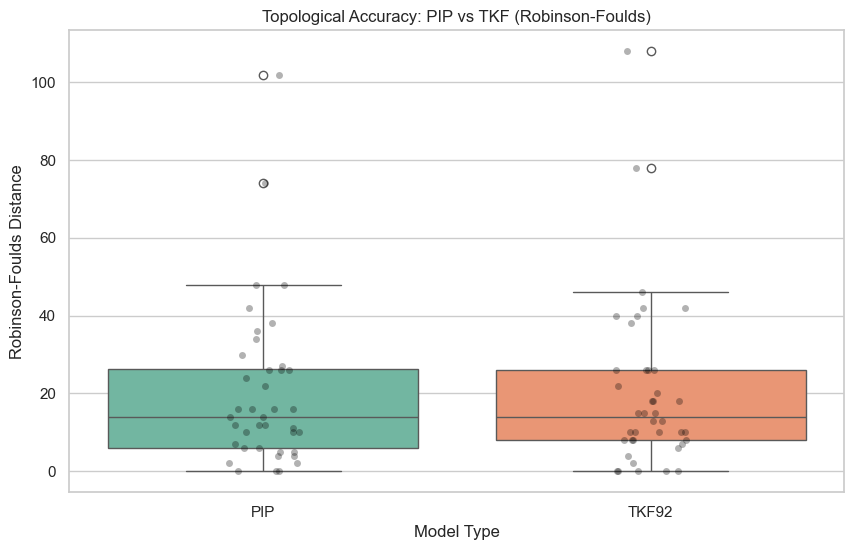

Mann-Whitney U test (RF distance): p-value = 0.8927
No statistically significant difference found.


In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x=model_col, y='robinson_foulds', hue=model_col, palette='Set2', legend=False)
sns.stripplot(data=df, x=model_col, y='robinson_foulds', color='black', alpha=0.3)
plt.title('Topological Accuracy: PIP vs TKF (Robinson-Foulds)')
plt.ylabel('Robinson-Foulds Distance')
plt.xlabel('Model Type')
plt.show()

# Statistical significance test (Mann-Whitney U)
pip_data = df[df[model_col] == 'PIP']['robinson_foulds'].dropna()
tkf_data = df[df[model_col] == 'TKF92']['robinson_foulds'].dropna()

if not pip_data.empty and not tkf_data.empty:
    u_stat, p_val = mannwhitneyu(pip_data, tkf_data)
    print(f"Mann-Whitney U test (RF distance): p-value = {p_val:.4f}")
    if p_val < 0.05:
        print("Statistically significant difference between models.")
    else:
        print("No statistically significant difference found.")

## 2. Accuracy vs Data Quality (Gap Percentage)

This plot shows how the models handle increasing amounts of missing data (gaps).

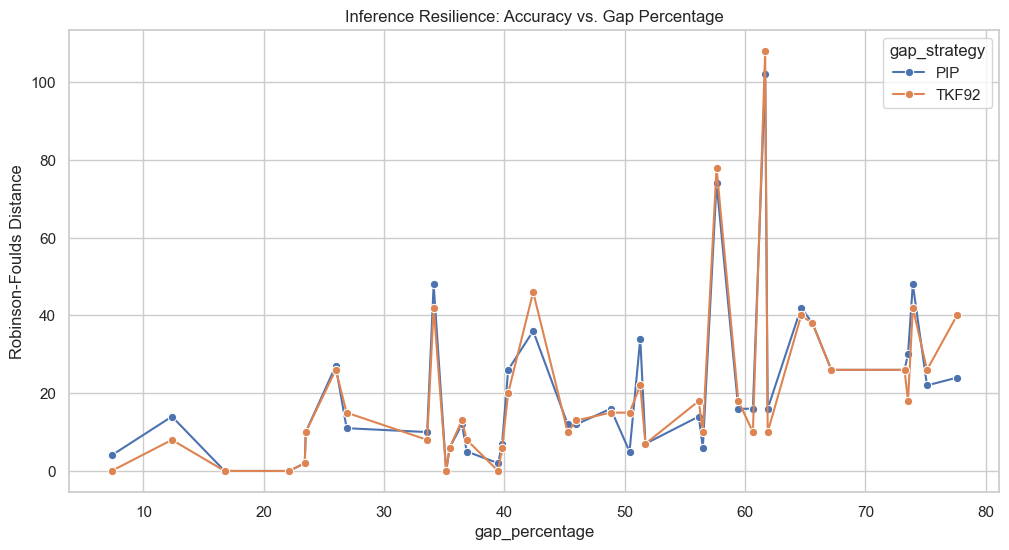

In [22]:
if 'gap_percentage' in df.columns:
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df, x='gap_percentage', y='robinson_foulds', hue=model_col, marker='o')
    plt.title('Inference Resilience: Accuracy vs. Gap Percentage')
    plt.ylabel('Robinson-Foulds Distance')
    plt.show()

## 3. Computational Complexity Analysis (OLS Regression)

We expect the runtime ($T$) of these models to scale roughly as:
$$T \propto \text{species}^2 \times \text{alignment\_length}$$

We will fit a linear model $T = \beta_0 + \beta_1 X$, where $X = \text{species}^2 \times \text{alignment\_length}$.


==================== TKF92 Complexity Analysis ====================
                            OLS Regression Results                            
Dep. Variable:        runtime_seconds   R-squared:                       0.626
Model:                            OLS   Adj. R-squared:                  0.616
Method:                 Least Squares   F-statistic:                     61.93
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           2.03e-09
Time:                        19:14:30   Log-Likelihood:                -309.76
No. Observations:                  39   AIC:                             623.5
Df Residuals:                      37   BIC:                             626.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

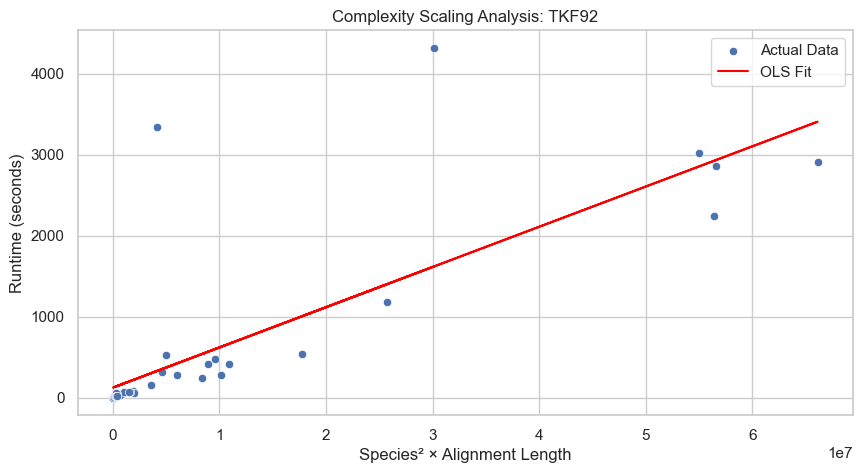


==================== PIP Complexity Analysis ====================
                            OLS Regression Results                            
Dep. Variable:        runtime_seconds   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.966
Method:                 Least Squares   F-statistic:                     901.2
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           1.77e-24
Time:                        19:14:30   Log-Likelihood:                -274.57
No. Observations:                  33   AIC:                             553.1
Df Residuals:                      31   BIC:                             556.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

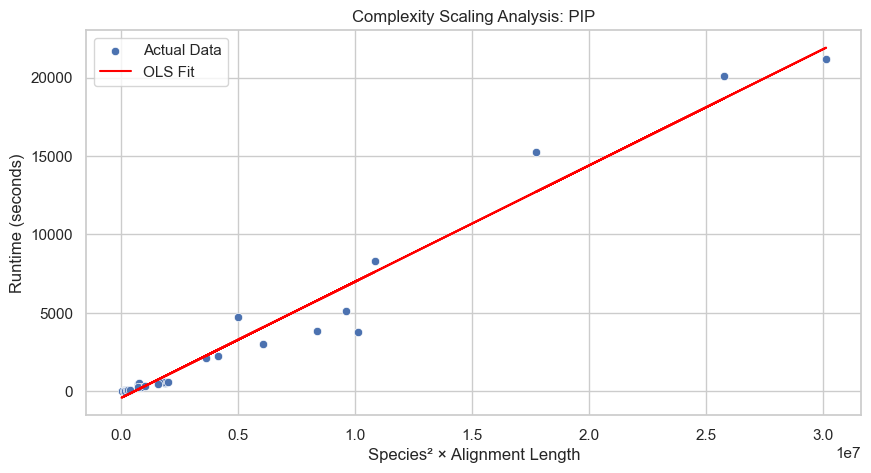

In [23]:
# Filter data
reg_df = df[df['runtime_seconds'] > 0].copy()

# Create the interaction feature: species^2 * alignment_length
reg_df['complexity_feature'] = (reg_df['species']**2) * reg_df['alignment_length']

for model in reg_df[model_col].unique():
    print(f"\n{'='*20} {model} Complexity Analysis {'='*20}")
    subset = reg_df[reg_df[model_col] == model]
    
    if len(subset) < 2:
        print(f"Not enough data points for {model}")
        continue
        
    X = subset[['complexity_feature']]
    X = sm.add_constant(X)
    y = subset['runtime_seconds']
    
    model_fit = sm.OLS(y, X).fit()
    print(model_fit.summary())
    
    # Visualization
    plt.figure(figsize=(10, 5))
    sns.scatterplot(x=subset['complexity_feature'], y=y, label='Actual Data')
    plt.plot(subset['complexity_feature'], model_fit.predict(X), color='red', label='OLS Fit')
    plt.title(f'Complexity Scaling Analysis: {model}')
    plt.xlabel('Species² × Alignment Length')
    plt.ylabel('Runtime (seconds)')
    plt.legend()
    plt.show()

## 4. Branch Length Accuracy (Kuhner-Felsenstein)

The Kuhner-Felsenstein distance accounts for both topology and branch length estimation accuracy.

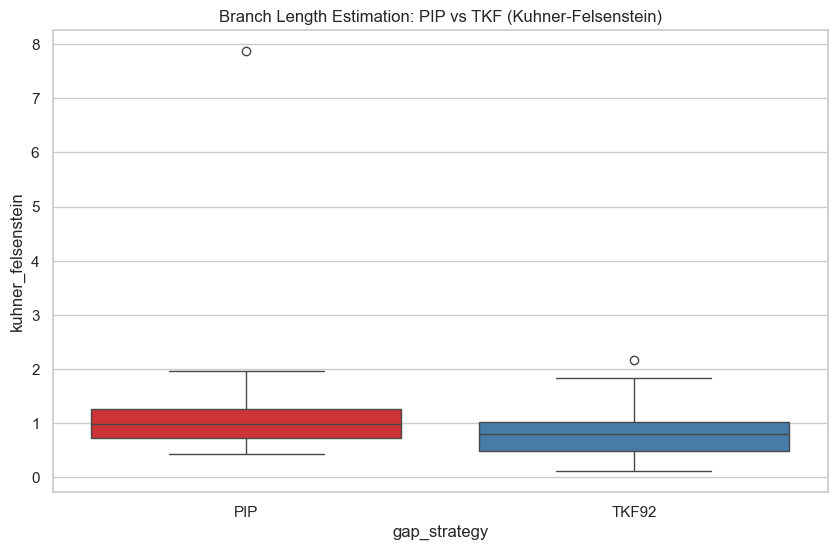

In [24]:
if 'kuhner_felsenstein' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=model_col, y='kuhner_felsenstein', hue=model_col, palette='Set1', legend=False)
    plt.title('Branch Length Estimation: PIP vs TKF (Kuhner-Felsenstein)')
    plt.show()

## 5. Stratified Accuracy Analysis

We compare **Robinson-Foulds (RF)** and **Kuhner-Felsenstein (KF)** distances across different **tree sizes** (number of species) and **MSA simulation tools**.

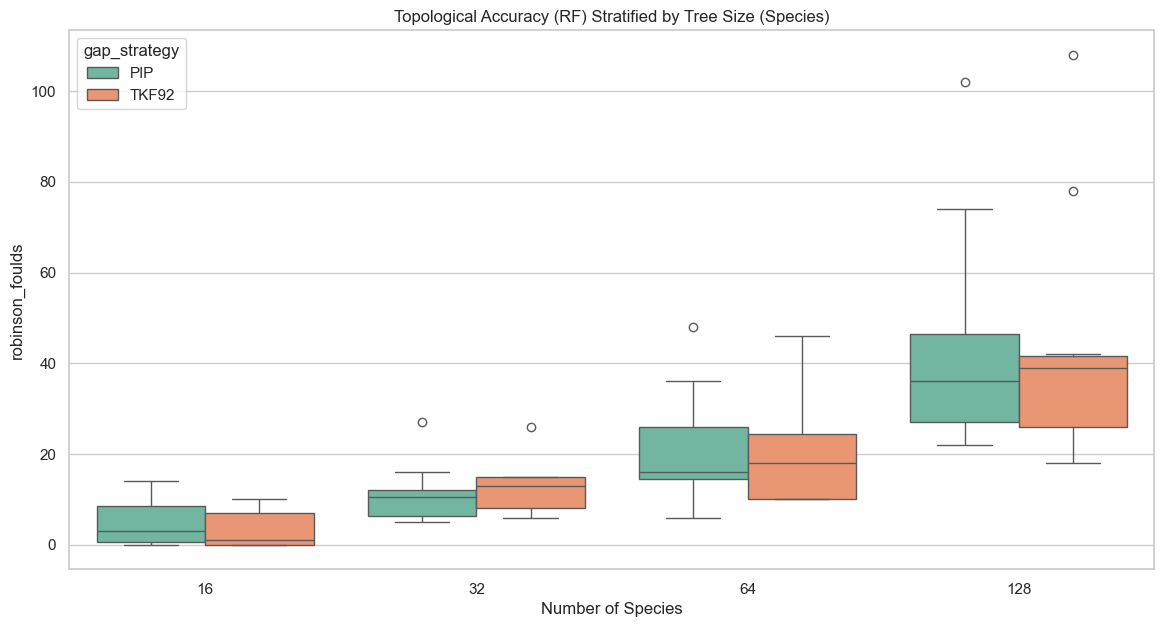

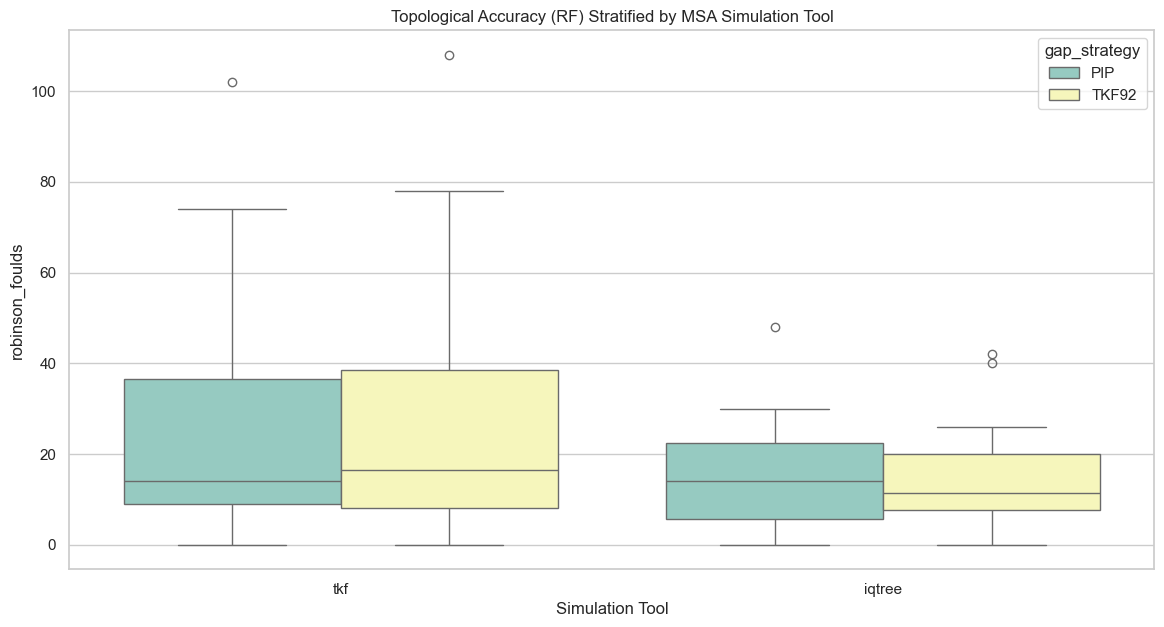

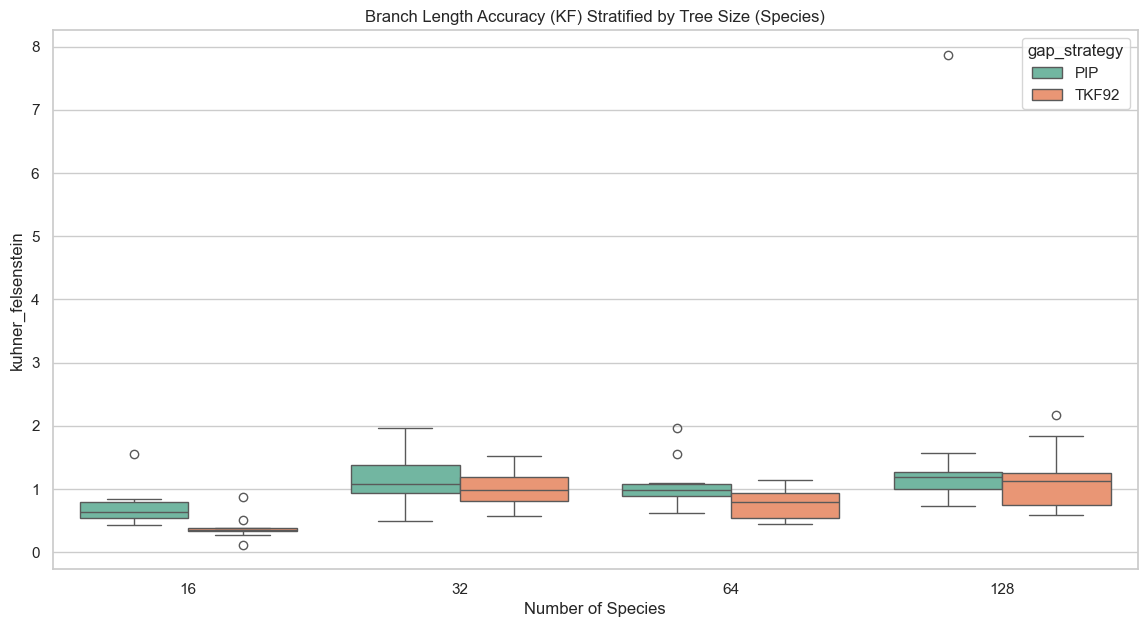

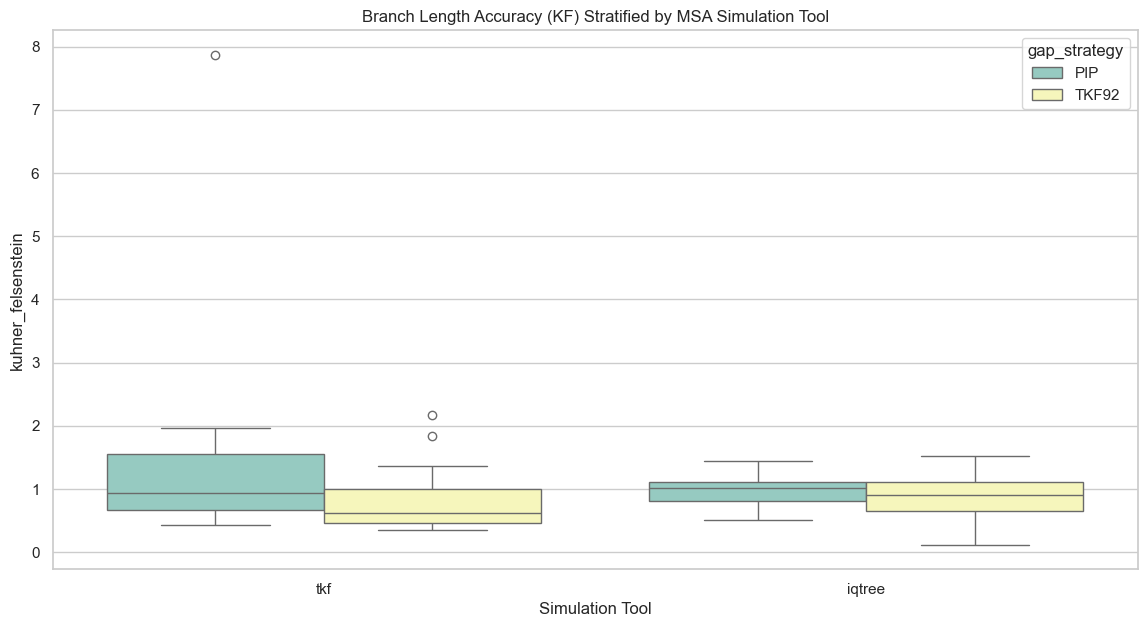

In [25]:
def plot_stratified(metric, title_prefix):
    if metric not in df.columns: return
    
    # 1. Stratify by Tree Size (Species)
    plt.figure(figsize=(14, 7))
    sns.boxplot(data=df, x='species', y=metric, hue=model_col, palette='Set2')
    plt.title(f'{title_prefix} Stratified by Tree Size (Species)')
    plt.ylabel(metric)
    plt.xlabel('Number of Species')
    plt.show()

    # 2. Stratify by MSA Simulation Tool
    if 'msa_sim_tool' in df.columns:
        plt.figure(figsize=(14, 7))
        sns.boxplot(data=df, x='msa_sim_tool', y=metric, hue=model_col, palette='Set3')
        plt.title(f'{title_prefix} Stratified by MSA Simulation Tool')
        plt.ylabel(metric)
        plt.xlabel('Simulation Tool')
        plt.show()

plot_stratified('robinson_foulds', 'Topological Accuracy (RF)')
plot_stratified('kuhner_felsenstein', 'Branch Length Accuracy (KF)')